In [1]:
# ============================================================
# UK Greenhouse Gas Emissions Analysis (1990–2023)
# Data source: DESNZ Final UK GHG Emissions Statistics 2023
# ============================================================

In [4]:
# ── Cell 1: 导入库 & 路径设置 ─────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

DATA_PATH = "C:/Users/888/Desktop/UCL Moduels/AFinal_BENV0096 Dissertation Energy Systems and Data Analytics/Data_raw/A_CB6/final-greenhouse-gas-emissions-tables-2023.xlsx"  # ← 修改为本地路径

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

YEARS = list(range(1990, 2024))

In [5]:
# ── Cell 2: 读取 Sheet 1.1 ────────────────────────────────
df_11 = pd.read_excel(DATA_PATH, sheet_name="1.1", header=None)
data_rows = list(range(6, 14))
gases_raw = df_11.iloc[data_rows, 0].str.strip().tolist()
values_11 = df_11.iloc[data_rows, 1:35].astype(float)
values_11.columns = YEARS
values_11.index = gases_raw

gases_order = [
    "Net CO2 emissions (emissions minus removals)",
    "Methane (CH4)", "Nitrous oxide (N2O)",
    "Hydrofluorocarbons (HFCs)", "Perfluorocarbons (PFCs)",
    "Sulphur hexafluoride (SF6)", "Nitrogen trifluoride (NF3)",
]
gas_labels = ["CO₂", "CH₄", "N₂O", "HFCs", "PFCs", "SF₆", "NF₃"]
total_row = values_11.loc["Total greenhouse gas emissions"]
gas_data  = values_11.loc[gases_order]

print("✅ Sheet 1.1 — Total GHG 1990:", round(total_row[1990], 1),
      "MtCO₂e | 2023:", round(total_row[2023], 1), "MtCO₂e |",
      "Reduction:", round((1 - total_row[2023]/total_row[1990])*100, 1), "%")

✅ Sheet 1.1 — Total GHG 1990: 810.7 MtCO₂e | 2023: 385.0 MtCO₂e | Reduction: 52.5 %


In [6]:
# ── Cell 3: 读取 Sheet 1.2 部门数据 ──────────────────────
df_12 = pd.read_excel(DATA_PATH, sheet_name="1.2", header=None)
SECTOR_ROWS = {
    "Electricity supply": 11, "Fuel supply": 29,
    "Transport": 51,          "Buildings": 64,
    "Industry": 93,           "Agriculture": 117,
    "Waste": 124,             "LULUCF": 159,
}
sectors = {}
for name, row_idx in SECTOR_ROWS.items():
    vals = df_12.iloc[row_idx, 3:37].astype(float).values
    sectors[name] = vals
df_sectors = pd.DataFrame(sectors, index=YEARS)
print("✅ Sheet 1.2 loaded")

✅ Sheet 1.2 loaded


In [7]:
# ── Cell 4: 读取 Sheet 2.1 — 官方 Net Carbon Account ────
df_21 = pd.read_excel(DATA_PATH, sheet_name="2.1", header=None)

# 直接读取官方5年合计（CB1/2/3的Net Carbon Account totals）
cb_nca_actuals = {
    "CB1\n(2008–12)": float(df_21.iloc[13, 7]),   # 2981.5
    "CB2\n(2013–17)": float(df_21.iloc[20, 7]),   # 2398.1
    "CB3\n(2018–22)": float(df_21.iloc[27, 7]),   # 2152.8
}
cb_targets = {
    "CB1\n(2008–12)": 3018,
    "CB2\n(2013–17)": 2782,
    "CB3\n(2018–22)": 2544,
}
print("✅ Sheet 2.1 — Net Carbon Account totals:")
for k, v in cb_nca_actuals.items():
    print(f"   {k.replace(chr(10),' ')}: {v:.1f} MtCO₂e (target: {cb_targets[k]})")

annual_total = total_row.copy()


✅ Sheet 2.1 — Net Carbon Account totals:
   CB1 (2008–12): 2981.5 MtCO₂e (target: 3018)
   CB2 (2013–17): 2398.1 MtCO₂e (target: 2782)
   CB3 (2018–22): 2152.8 MtCO₂e (target: 2544)


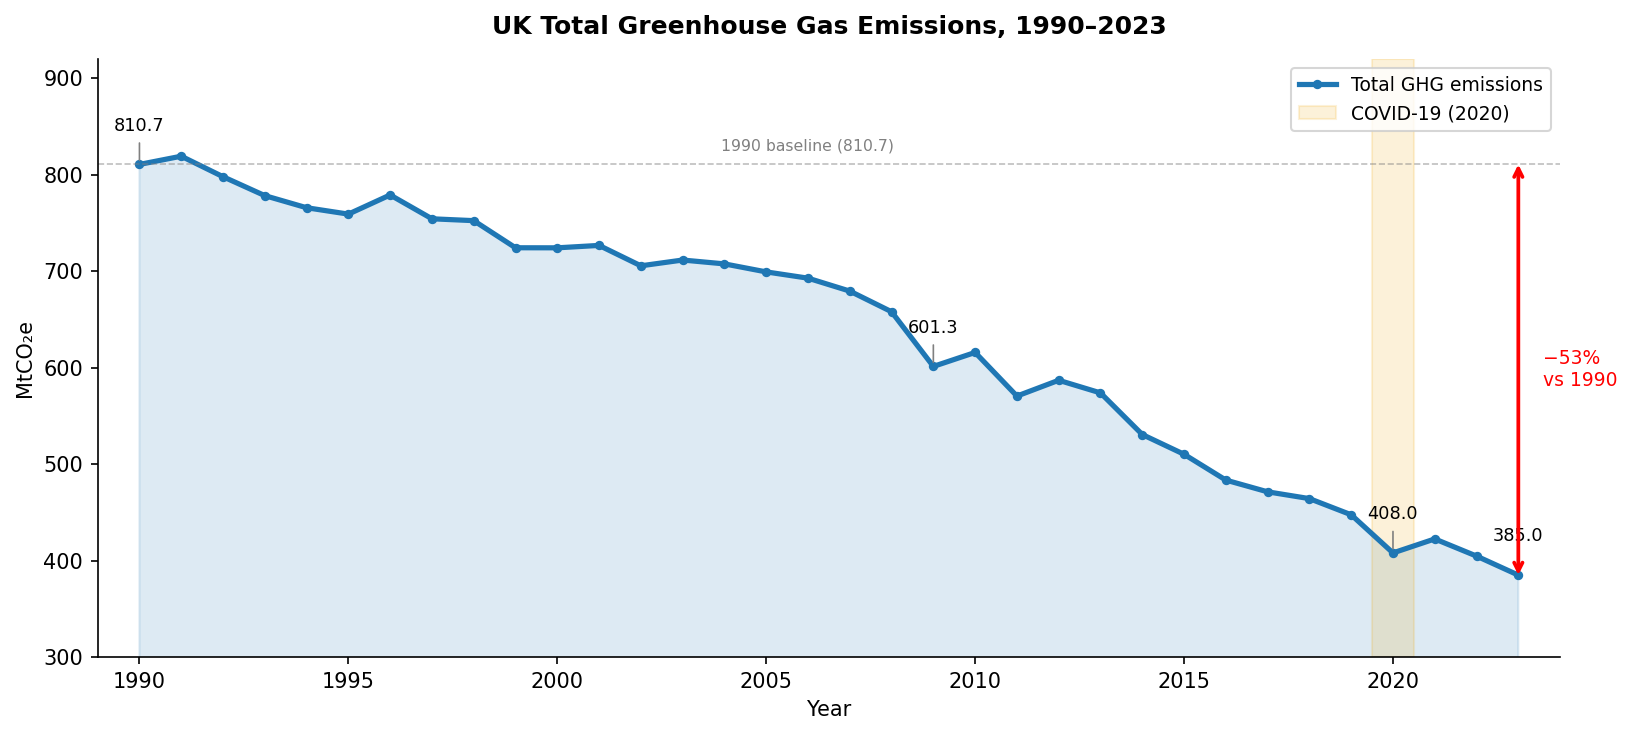

✅ Fig 1 saved: fig1_total_ghg_trend.png


In [14]:
# ── Cell 5: 图1 — UK GHG 总排放趋势（1990–2023）───────────
val_1990 = float(total_row[1990])
val_2023 = float(total_row[2023])
pct = (1 - val_2023 / val_1990) * 100

fig, ax = plt.subplots(figsize=(11, 5))

ax.fill_between(YEARS, total_row.values, alpha=0.15, color="#1f77b4")
ax.plot(YEARS, total_row.values, color="#1f77b4", lw=2.5,
        marker="o", markersize=3.5, label="Total GHG emissions")

# 关键年份标注
for yr, offset in [(1990, 35), (2009, 35), (2020, 35), (2023, 35)]:
    val = round(total_row[yr], 1)
    ax.annotate(f"{val}", xy=(yr, val), xytext=(yr, val + offset),
                ha="center", fontsize=8.5,
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.8))

# COVID 标记
ax.axvspan(2019.5, 2020.5, alpha=0.15, color="#f0a500", label="COVID-19 (2020)")

# 基线参考线
ax.axhline(val_1990, color="grey", lw=0.8, ls="--", alpha=0.5)
ax.text(2006, val_1990 + 14, "1990 baseline (810.7)",
        ha="center", fontsize=7.5, color="grey")

# 减排双向箭头
ax.annotate("",
            xy    =(2023, val_1990),
            xytext=(2023, val_2023),
            xycoords="data",
            arrowprops=dict(
                arrowstyle="<->",
                color="red",
                lw=1.8,
                shrinkA=0,
                shrinkB=0,
            ))
ax.text(2023.6, (val_1990 + val_2023) / 2,
        f"−{pct:.0f}%\nvs 1990", color="red", fontsize=9, va="center")

ax.set_xlim(1989, 2024)
ax.set_ylim(300, 920)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("MtCO₂e", fontsize=10)
ax.set_title("UK Total Greenhouse Gas Emissions, 1990–2023",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=9, loc="upper right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))

plt.tight_layout()
plt.savefig("fig1_total_ghg_trend.png", bbox_inches="tight")
plt.show()
print("✅ Fig 1 saved: fig1_total_ghg_trend.png")


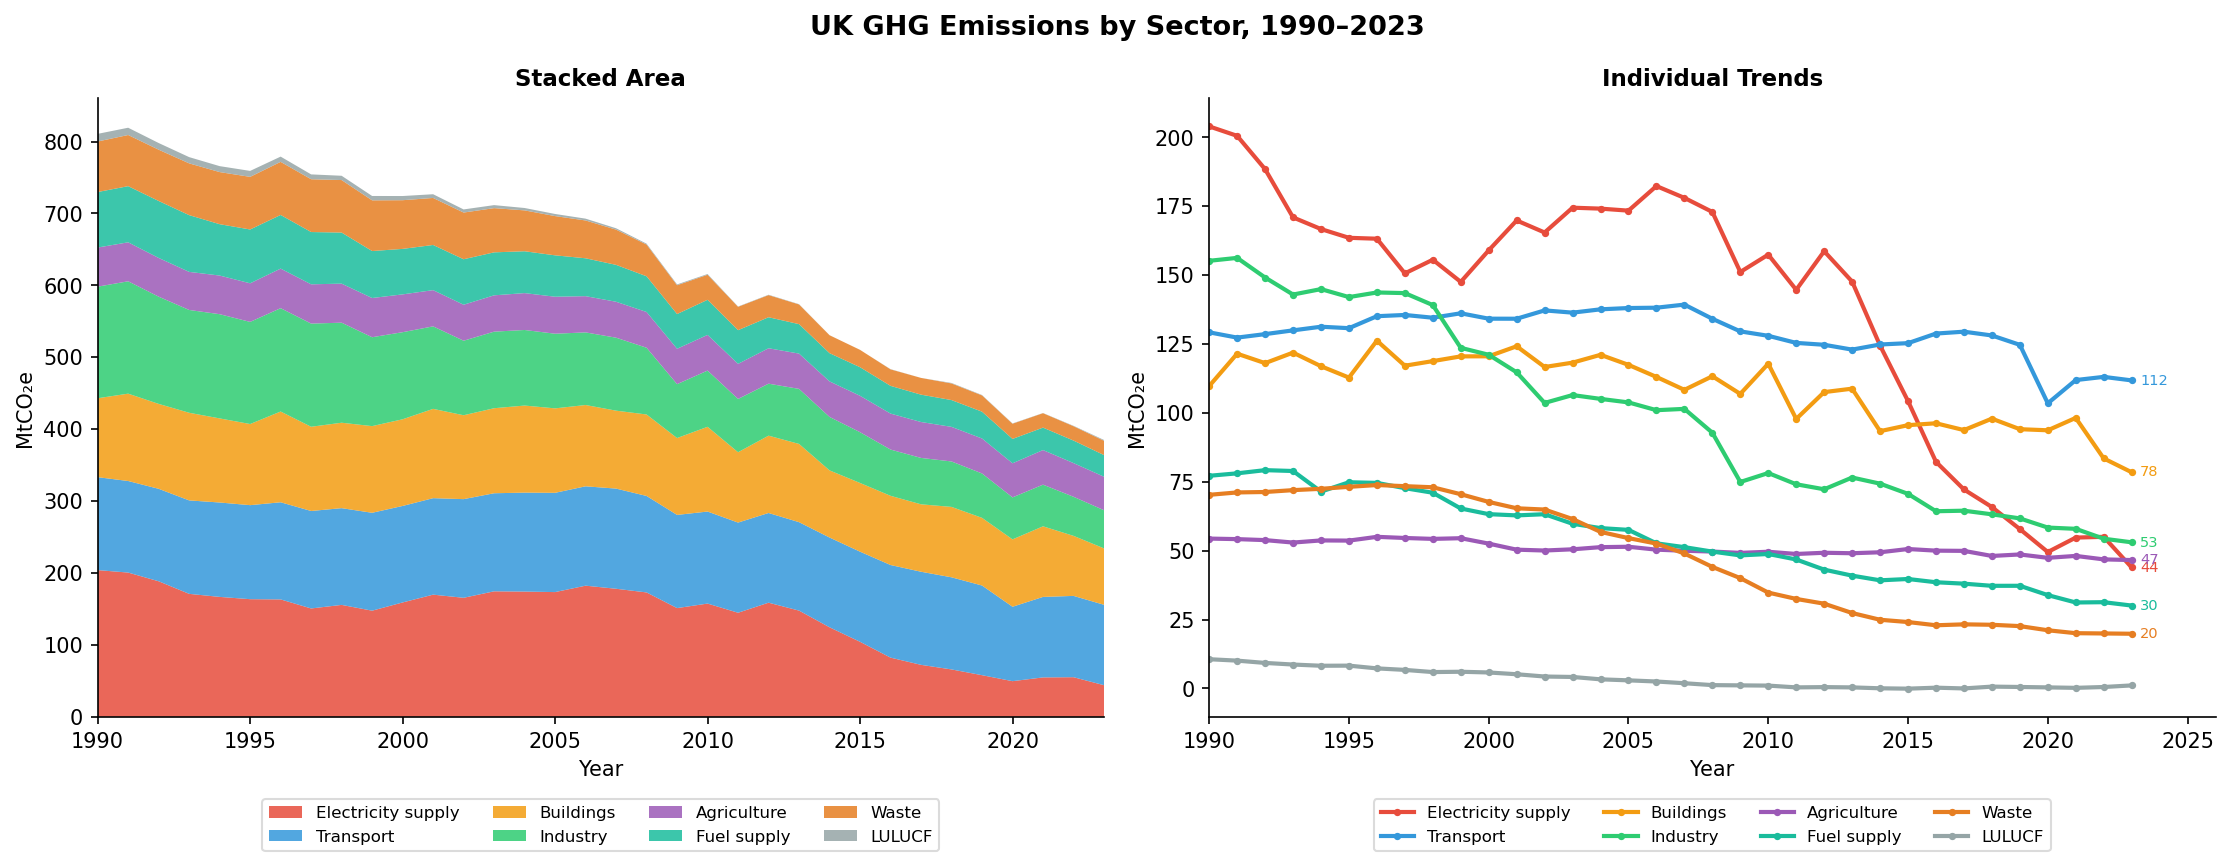

✅ Fig 2 saved


In [9]:
# ── Cell 6: 图2 — 部门排放（修复：图例移图外）──────────────
SECTOR_COLORS = {
    "Electricity supply": "#e74c3c",
    "Transport":          "#3498db",
    "Buildings":          "#f39c12",
    "Industry":           "#2ecc71",
    "Agriculture":        "#9b59b6",
    "Fuel supply":        "#1abc9c",
    "Waste":              "#e67e22",
    "LULUCF":             "#95a5a6",
}
sector_cols = list(SECTOR_COLORS.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 左：堆叠面积
ax1.stackplot(YEARS,
              [df_sectors[s].values for s in sector_cols],
              labels=sector_cols,
              colors=[SECTOR_COLORS[s] for s in sector_cols],
              alpha=0.85)
ax1.set_xlim(1990, 2023)
ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("MtCO₂e", fontsize=10)
ax1.set_title("Stacked Area", fontsize=11, fontweight="bold")
# 图例放图外下方
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
           ncol=4, fontsize=8, framealpha=0.7)

# 右：折线（修复：图例放图外右侧）
for s in sector_cols:
    ax2.plot(YEARS, df_sectors[s].values,
             color=SECTOR_COLORS[s], lw=2, label=s,
             marker="o", markersize=2.5)
# 2023年终点标注数值
for s in sector_cols:
    val = df_sectors.loc[2023, s]
    if val > 8:  # 只标注较大值，避免重叠
        ax2.text(2023.3, val, f"{val:.0f}", fontsize=7,
                 color=SECTOR_COLORS[s], va="center")
ax2.set_xlim(1990, 2026)
ax2.set_xlabel("Year", fontsize=10)
ax2.set_ylabel("MtCO₂e", fontsize=10)
ax2.set_title("Individual Trends", fontsize=11, fontweight="bold")
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
           ncol=4, fontsize=8, framealpha=0.7)

plt.suptitle("UK GHG Emissions by Sector, 1990–2023",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.savefig("fig2_sectoral_emissions.png", bbox_inches="tight")
plt.show()
print("✅ Fig 2 saved")

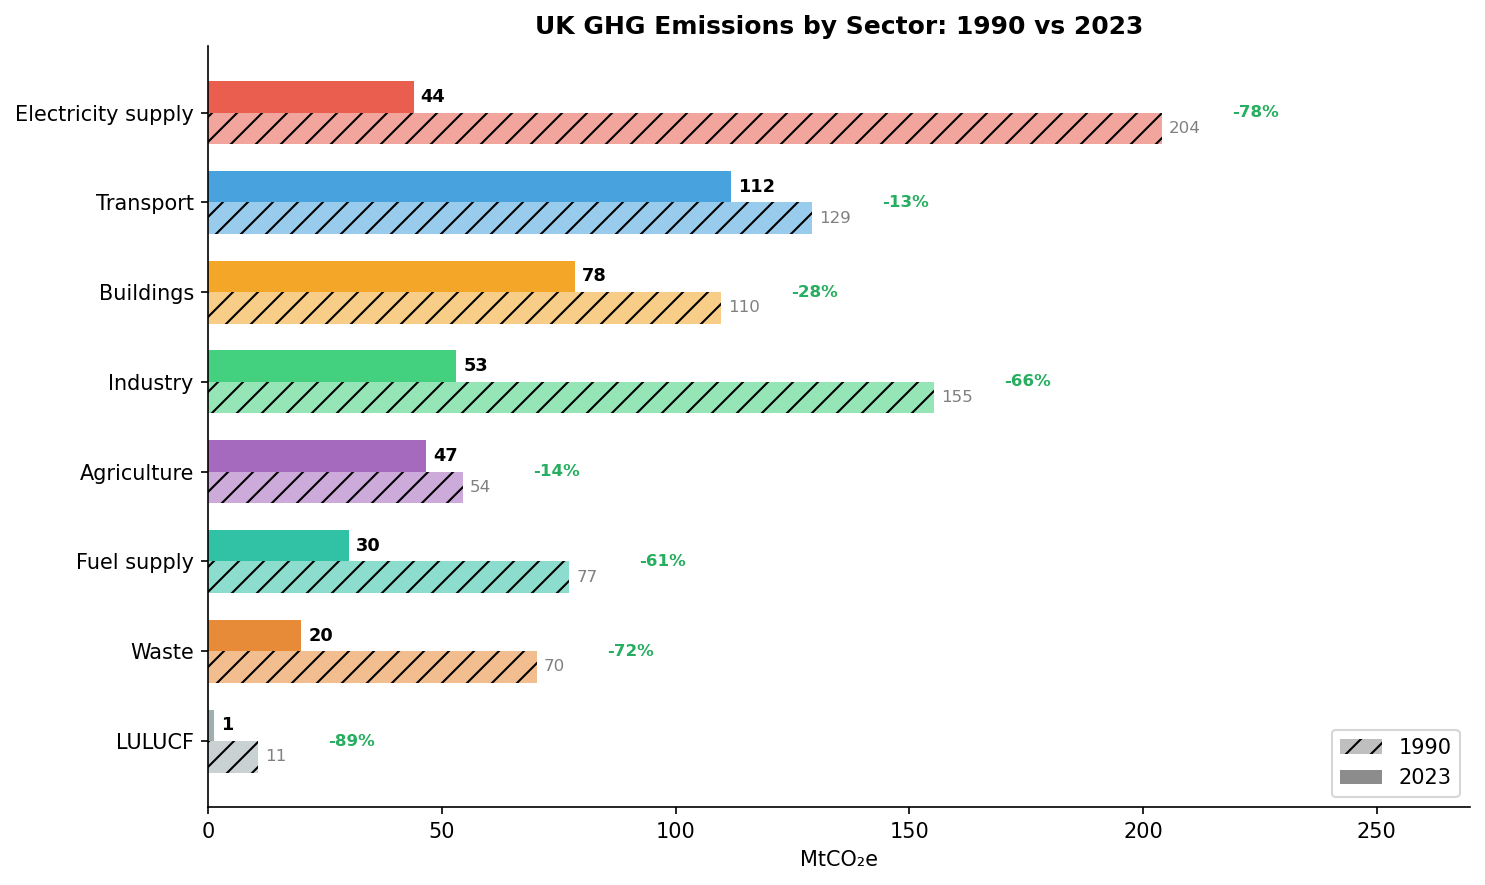

✅ Fig 3 saved


In [10]:
# ── Cell 7: 图3 — 部门结构对比（修复：改为水平条形图）────────
fig, ax = plt.subplots(figsize=(10, 6))

vals_1990 = df_sectors.loc[1990, sector_cols].values
vals_2023 = df_sectors.loc[2023, sector_cols].values

y = np.arange(len(sector_cols))
h = 0.35
bars_1990 = ax.barh(y + h/2, vals_1990, h,
                    color=[SECTOR_COLORS[s] for s in sector_cols],
                    alpha=0.5, label="1990", hatch="//")
bars_2023 = ax.barh(y - h/2, vals_2023, h,
                    color=[SECTOR_COLORS[s] for s in sector_cols],
                    alpha=0.9, label="2023")

# 标注数值
for i, (v90, v23) in enumerate(zip(vals_1990, vals_2023)):
    ax.text(v90 + 1.5, i + h/2, f"{v90:.0f}", va="center", fontsize=8, color="grey")
    ax.text(v23 + 1.5, i - h/2, f"{v23:.0f}", va="center", fontsize=8.5, fontweight="bold")

# 标注变化率
for i, (v90, v23) in enumerate(zip(vals_1990, vals_2023)):
    chg = (v23 - v90) / v90 * 100
    color = "#27ae60" if chg < 0 else "#c0392b"
    ax.text(max(v90, v23) + 15, i, f"{chg:+.0f}%",
            va="center", fontsize=8, color=color, fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(sector_cols, fontsize=10)
ax.set_xlabel("MtCO₂e", fontsize=10)
ax.set_title("UK GHG Emissions by Sector: 1990 vs 2023",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 270)

# 手动图例（区分1990/2023）
legend_elements = [
    mpatches.Patch(facecolor="grey", alpha=0.5, hatch="//", label="1990"),
    mpatches.Patch(facecolor="grey", alpha=0.9, label="2023"),
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("fig3_sector_compare.png", bbox_inches="tight")
plt.show()
print("✅ Fig 3 saved")


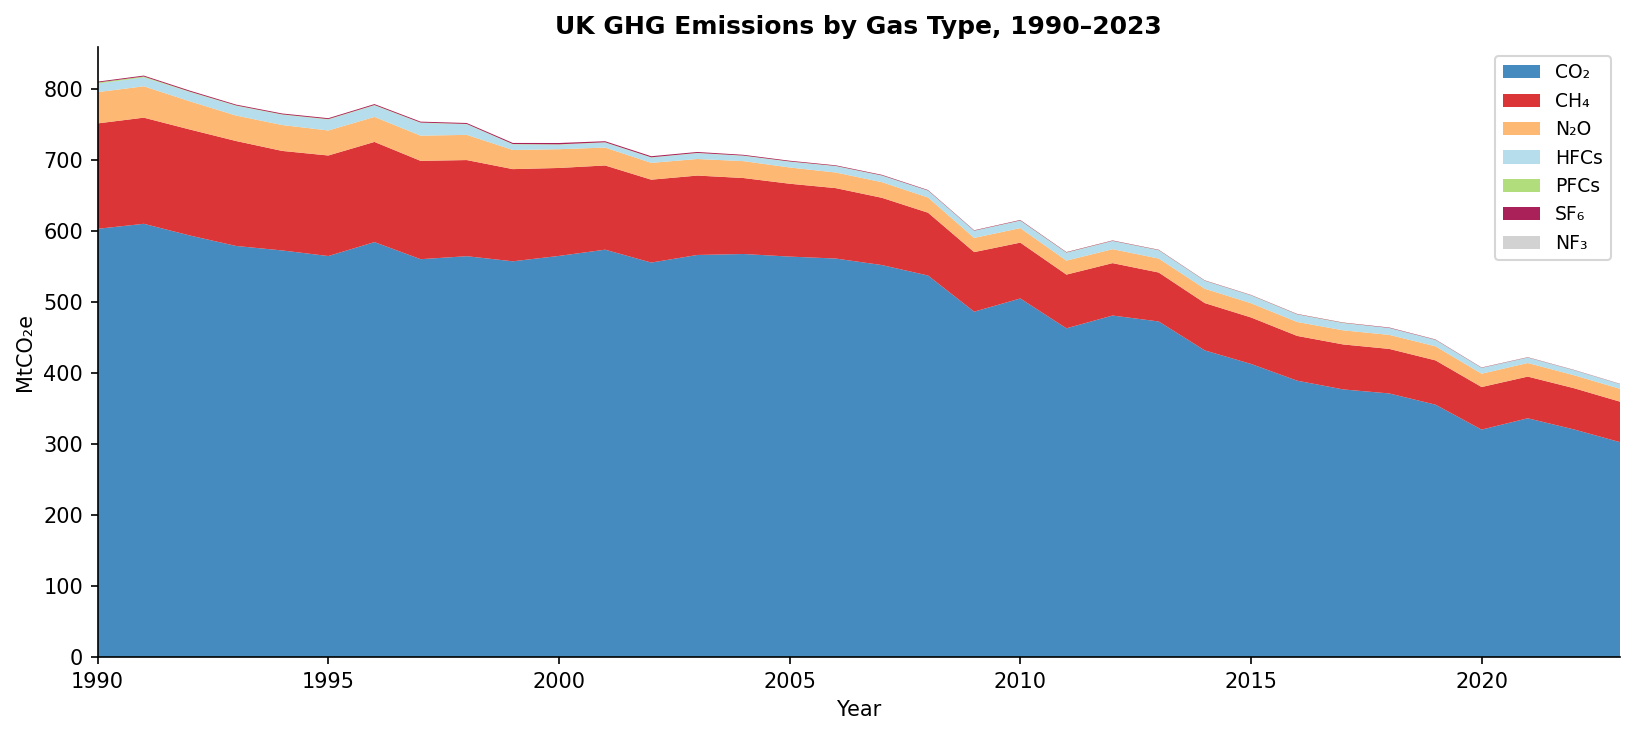

✅ Fig 4 saved


In [11]:
# ── Cell 8: 图4 — 气体类型堆叠（保持原样）──────────────────
fig, ax = plt.subplots(figsize=(11, 5))

GAS_COLORS = {
    "CO₂": "#2c7bb6", "CH₄": "#d7191c", "N₂O": "#fdae61",
    "HFCs": "#abd9e9", "PFCs": "#a6d96a", "SF₆": "#9e0142", "NF₃": "#cccccc",
}
ax.stackplot(YEARS,
             [gas_data.loc[g].values for g in gases_order],
             labels=gas_labels,
             colors=list(GAS_COLORS.values()),
             alpha=0.88)
ax.set_xlim(1990, 2023)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("MtCO₂e", fontsize=10)
ax.set_title("UK GHG Emissions by Gas Type, 1990–2023",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("fig4_ghg_by_gas.png", bbox_inches="tight")
plt.show()
print("✅ Fig 4 saved")

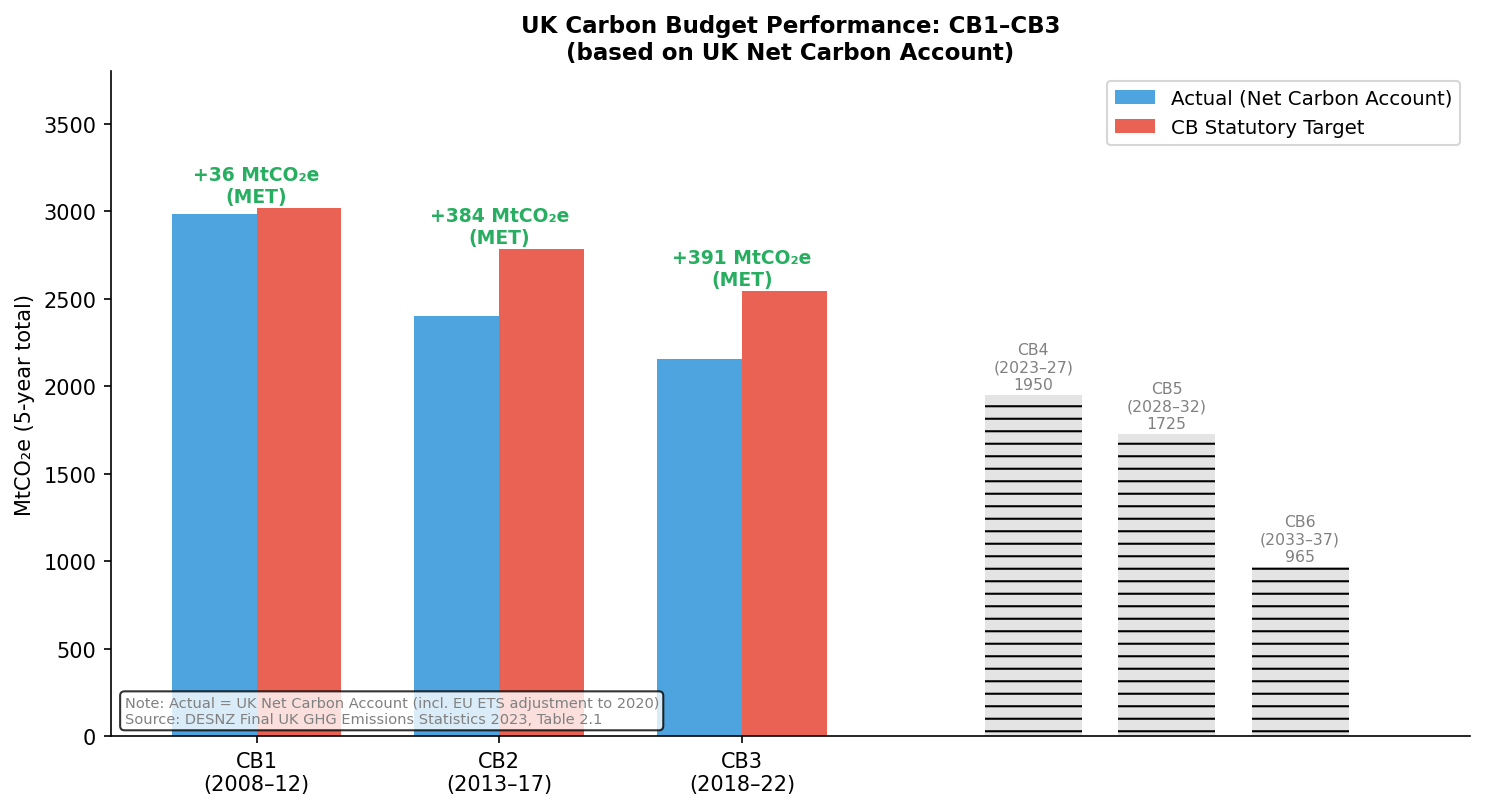

✅ Fig 5 saved


In [12]:
# ── Cell 9: 图5 — Carbon Budget（修复：用官方Net Carbon Account）
fig, ax = plt.subplots(figsize=(10, 5.5))

cb_labels = list(cb_nca_actuals.keys())
cb_act    = list(cb_nca_actuals.values())
cb_tgt    = list(cb_targets.values())

x = np.arange(len(cb_labels))
w = 0.35
ax.bar(x - w/2, cb_act, w, label="Actual (Net Carbon Account)",
       color="#3498db", alpha=0.88)
ax.bar(x + w/2, cb_tgt, w, label="CB Statutory Target",
       color="#e74c3c", alpha=0.88)

# 差值标注
for i, (act, tgt) in enumerate(zip(cb_act, cb_tgt)):
    diff = tgt - act
    color = "#27ae60" if diff > 0 else "#c0392b"
    sign  = "+" if diff > 0 else ""
    label_y = max(act, tgt) + 35
    ax.text(x[i], label_y,
            f"{sign}{diff:.0f} MtCO₂e\n({'MET' if diff>0 else 'MISSED'})",
            ha="center", fontsize=9, color=color, fontweight="bold")

# 未来CB目标（灰色虚线）
future = {"CB4\n(2023–27)": 1950, "CB5\n(2028–32)": 1725, "CB6\n(2033–37)": 965}
for j, (lbl, tgt) in enumerate(future.items()):
    fx = 3.2 + j * 0.55
    ax.bar(fx, tgt, 0.4, color="lightgrey", alpha=0.6, hatch="--")
    ax.text(fx, tgt + 35, f"{lbl}\n{tgt}", ha="center",
            fontsize=7.5, color="grey")

ax.set_xticks(x)
ax.set_xticklabels(cb_labels, fontsize=10)
ax.set_ylabel("MtCO₂e (5-year total)", fontsize=10)
ax.set_ylim(0, 3800)
ax.set_xlim(-0.6, 5.0)
ax.set_title("UK Carbon Budget Performance: CB1–CB3\n(based on UK Net Carbon Account)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9.5)
ax.text(0.01, 0.02,
        "Note: Actual = UK Net Carbon Account (incl. EU ETS adjustment to 2020)\n"
        "Source: DESNZ Final UK GHG Emissions Statistics 2023, Table 2.1",
        transform=ax.transAxes, fontsize=7, color="grey",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("fig5_carbon_budget_progress.png", bbox_inches="tight")
plt.show()
print("✅ Fig 5 saved")

In [13]:
# ── Cell 10: 汇总统计 ─────────────────────────────────────
print("\n" + "="*60)
print("UK GHG Emissions — Key Statistics Summary")
print("="*60)

print(f"\n📊 Total GHG Emissions:")
for yr in [1990, 2000, 2005, 2010, 2015, 2019, 2020, 2023]:
    flag = " ← COVID" if yr == 2020 else ""
    print(f"   {yr}: {annual_total[yr]:.1f} MtCO₂e{flag}")
print(f"   Reduction 1990→2023: {(1 - annual_total[2023]/annual_total[1990])*100:.1f}%")

print(f"\n📊 Sector shares in 2023:")
total_2023 = df_sectors.loc[2023, sector_cols].sum()
for s in sector_cols:
    share  = df_sectors.loc[2023, s] / total_2023 * 100
    change = df_sectors.loc[2023, s] - df_sectors.loc[1990, s]
    pct_ch = change / df_sectors.loc[1990, s] * 100
    print(f"   {s:<22}: {df_sectors.loc[2023,s]:6.1f} MtCO₂e  "
          f"({share:.1f}%)  [Δ vs 1990: {change:+.1f}, {pct_ch:+.0f}%]")

print(f"\n📊 Carbon Budget Performance (Net Carbon Account):")
for lbl, act, tgt in zip(cb_labels, cb_act, cb_tgt):
    status = "✅ MET" if act <= tgt else "❌ MISSED"
    margin = tgt - act
    print(f"   {lbl.replace(chr(10),' ')}: "
          f"Actual={act:.0f}  Target={tgt}  Margin={margin:+.0f}  {status}")



UK GHG Emissions — Key Statistics Summary

📊 Total GHG Emissions:
   1990: 810.7 MtCO₂e
   2000: 724.3 MtCO₂e
   2005: 699.3 MtCO₂e
   2010: 615.8 MtCO₂e
   2015: 510.2 MtCO₂e
   2019: 447.5 MtCO₂e
   2020: 408.0 MtCO₂e ← COVID
   2023: 385.0 MtCO₂e
   Reduction 1990→2023: 52.5%

📊 Sector shares in 2023:
   Electricity supply    :   43.9 MtCO₂e  (11.4%)  [Δ vs 1990: -160.1, -78%]
   Transport             :  111.8 MtCO₂e  (29.0%)  [Δ vs 1990: -17.4, -13%]
   Buildings             :   78.5 MtCO₂e  (20.4%)  [Δ vs 1990: -31.3, -28%]
   Industry              :   53.1 MtCO₂e  (13.8%)  [Δ vs 1990: -102.2, -66%]
   Agriculture           :   46.6 MtCO₂e  (12.1%)  [Δ vs 1990: -7.8, -14%]
   Fuel supply           :   30.1 MtCO₂e  (7.8%)  [Δ vs 1990: -47.1, -61%]
   Waste                 :   19.9 MtCO₂e  (5.2%)  [Δ vs 1990: -50.4, -72%]
   LULUCF                :    1.1 MtCO₂e  (0.3%)  [Δ vs 1990: -9.5, -89%]

📊 Carbon Budget Performance (Net Carbon Account):
   CB1 (2008–12): Actual=2982  Target